# 📘 CÁLCULO NUMÉRICO — NOTEBOOK MAESTRO DE EXAMEN

**Universidad U-tad**

> **Objetivo:** dominar el examen en 48h partiendo desde cero.  
> **Estructura del examen:** 40% test · 60% ejercicios (2 cortos + 2 largos).  
> **Filosofía:** orden incremental de dificultad, teoría mínima viable + ejercicios resueltos + ejercicios para ti.

---

## 🗺️ Mapa del notebook

| Bloque | Tema | Páginas relativas | Importancia |
|---|---|---|---|
| **0** | Setup y conceptos transversales | corto | ⭐⭐ |
| **1** | T1 — Errores, aritmética finita, cancelación | medio | ⭐⭐⭐ |
| **2** | T2 — Raíces: bisección, punto fijo, Newton, secante | LARGO | ⭐⭐⭐⭐⭐ |
| **3** | T4A — Derivación numérica (diferencias finitas) | medio | ⭐⭐⭐⭐ |
| **4** | T4B — EDOs (Euler, Heun, estabilidad) | LARGO | ⭐⭐⭐⭐⭐ |
| **5** | T4C — Diferenciación automática (números duales) | medio | ⭐⭐⭐ |
| **6** | T6 — Integración numérica (trapecio, Simpson, Gauss) | medio-largo | ⭐⭐⭐⭐ |
| **7** | 🎯 Batería tipo test (40 preguntas) | — | ⭐⭐⭐⭐⭐ |
| **8** | 🎯 Simulacro de examen completo (2 cortos + 2 largos) | — | ⭐⭐⭐⭐⭐ |

---

## 🧠 Cómo usar este notebook

1. **Lee la teoría mínima** de cada sección (está condensada al máximo).
2. **Ejecuta los ejemplos resueltos** y entiende cada línea.
3. **Haz los ejercicios propuestos sin mirar la solución** (están al final de cada sección).
4. **Cuando termines, ataca el Bloque 7 (test) y el Bloque 8 (simulacro)**.

> ⚠️ Si vas justo de tiempo: prioriza Bloques **2, 4 y 6** (la materia más probable en los ejercicios largos), y luego Bloque 7 (test).


---

# 📦 BLOQUE 0 — Setup y conceptos transversales

Importamos lo básico. **TODO el resto del notebook usa estas librerías.**


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import sys

# Para mostrar más decimales en los floats
np.set_printoptions(precision=12, suppress=False)

print("Versión de Python:", sys.version.split()[0])
print("Versión de NumPy:", np.__version__)
print("Épsilon de máquina (doble precisión):", sys.float_info.epsilon)

Versión de Python: 3.13.13
Versión de NumPy: 2.4.1
Épsilon de máquina (doble precisión): 2.220446049250313e-16


### ⚡ Conceptos que aparecen en TODOS los temas

- **Convergencia** = la sucesión {xₖ} se acerca a la solución verdadera x*.
- **Orden de convergencia r**: cómo de rápido. Lineal (r=1), superlineal (1<r<2), cuadrático (r=2).
- **Error**: diferencia entre el valor aproximado y el verdadero.
- **Tolerancia (tol)**: cuándo decimos "ya está bien" y paramos.
- **Iteración**: cada paso del proceso. `for k in range(maxit):` o `while error > tol:`.

> 💡 **Truco mental:** "más rápido converge → menos iteraciones → más caro por iteración (a veces)".


---

# 🟢 BLOQUE 1 — Tema 1: Errores y Aritmética Finita

## 1.1 Error absoluto vs error relativo

Sea $x$ el valor exacto (desconocido) y $\tilde{x}$ el aproximado.

$$\text{Error absoluto: } \Delta x = \tilde{x} - x$$
$$\text{Error relativo: } \delta x = \frac{\tilde{x} - x}{x} \quad (\text{si } x \neq 0)$$

**Regla mental:** el error absoluto cambia con la escala; el relativo no.

| Ejemplo | x | x̃ | Δx | δx |
|---|---|---|---|---|
| Caso A | 1.000 | 0.999 | −10⁻³ | −10⁻³ |
| Caso B | 10⁹ | 10⁹−1 | −1 | −10⁻⁹ |

Caso B parece "peor" en absoluto, pero está **muchísimo mejor aproximado** en relativo.


In [3]:
# Comparación absoluto/relativo
xA, xtA = 1.000, 0.999
xB, xtB = 1e9, 1e9 - 1

abs_A = xtA - xA
rel_A = abs_A / xA

abs_B = xtB - xB
rel_B = abs_B / xB

print(f"Caso A: |Δx|={abs(abs_A):.2e}  |δx|={abs(rel_A):.2e}")
print(f"Caso B: |Δx|={abs(abs_B):.2e}  |δx|={abs(rel_B):.2e}")

Caso A: |Δx|=1.00e-03  |δx|=1.00e-03
Caso B: |Δx|=1.00e+00  |δx|=1.00e-09


## 1.2 Propagación de errores

| Operación | Cota |
|---|---|
| $x = a \pm b$ | $\|\Delta x\| \le \|\Delta a\| + \|\Delta b\|$ (suman absolutos) |
| $x = a \cdot b$ o $x = a/b$ | $\|\delta x\| \le \|\delta a\| + \|\delta b\|$ (suman relativos) |

⚠️ **Cancelación catastrófica:** si $x = a - b$ con $a \approx b$, el denominador en la cota relativa $|a-b|$ es minúsculo y $|\delta x|$ explota.

$$|\delta x| \le \frac{|\Delta a| + |\Delta b|}{|a-b|}$$


In [4]:
# Cancelación catastrófica clásica: (1 - cos(x)) / x^2 para x -> 0
# Valor matemático: límite = 1/2

def f_directa(x):
    return (1 - np.cos(x)) / x**2

def f_estable(x):
    # Reformulación: (1-cos x)(1+cos x) = sin^2 x  =>  (1-cos x)/x^2 = sin^2(x) / (x^2 (1+cos x))
    return np.sin(x)**2 / (x**2 * (1 + np.cos(x)))

print(f"{'x':>10} {'directa':>20} {'estable':>20}")
for k in range(1, 11):
    x = 10.0**(-k)
    print(f"{x:>10.0e} {f_directa(x):>20.15f} {f_estable(x):>20.15f}")

print("\nValor exacto del límite cuando x->0: 0.5")

         x              directa              estable
     1e-01    0.499583472197418    0.499583472197423
     1e-02    0.499995833347366    0.499995833347222
     1e-03    0.499999958325503    0.499999958333335
     1e-04    0.499999996961265    0.499999999583333
     1e-05    0.500000041370185    0.499999999995833
     1e-06    0.500044450291171    0.499999999999958
     1e-07    0.499600361081320    0.500000000000000
     1e-08    0.000000000000000    0.500000000000000
     1e-09    0.000000000000000    0.500000000000000
     1e-10    0.000000000000000    0.500000000000000

Valor exacto del límite cuando x->0: 0.5


**Lectura del experimento:** la fórmula directa, a partir de $x \sim 10^{-8}$, pierde dígitos y acaba dando 0. La fórmula reformulada **mantiene 0.5** con precisión.

## 1.3 Aritmética de coma flotante: efectos sorprendentes


In [5]:
# Efectos clásicos de la aritmética finita
print("0.1 + 0.2 == 0.3 ?", 0.1 + 0.2 == 0.3)
print("0.1 + 0.2 =", 0.1 + 0.2)

print("\n--- Falta de asociatividad ---")
a = 1e20
print("(1e20 + (-1e20)) + 1.0 =", (a + (-a)) + 1.0)
print("1e20 + ((-1e20) + 1.0) =", a + ((-a) + 1.0))

print("\n--- Épsilon de máquina ---")
x = 1.0
while (1.0 + x != 1.0):
    x = x / 2.0
EPS = 2.0 * x
print(f"EPS calculado: {EPS}")
print(f"sys.float_info.epsilon: {sys.float_info.epsilon}")

0.1 + 0.2 == 0.3 ? False
0.1 + 0.2 = 0.30000000000000004

--- Falta de asociatividad ---
(1e20 + (-1e20)) + 1.0 = 1.0
1e20 + ((-1e20) + 1.0) = 0.0

--- Épsilon de máquina ---
EPS calculado: 2.220446049250313e-16
sys.float_info.epsilon: 2.220446049250313e-16


## 1.4 Representación en coma flotante: base b, mantisa t, exponente

Un número x se escribe como:
$$x = \pm 0.d_1 d_2 \ldots d_t \times b^n$$

con $1 \le d_1 \le b-1$, $0 \le d_i \le b-1$ para $i>1$, y $L \le n \le U$.

- **Mantisa**: dígitos significativos (precisión).
- **Exponente**: rango (overflow / underflow).
- **Overflow:** $n > U$. **Underflow:** $n < L$.

**Doble precisión (64 bits):** mantisa 52 bits, exponente 11 bits → ~15-16 dígitos decimales, rango ~$10^{\pm 308}$.

### Ejemplo típico de examen
**Sistema:** base $b=10$, mantisa $t=5$, exponente $L=-1$, $U=1$.

- Mayor representable: $0.99999 \times 10^1 = 9.9999$
- Menor positivo representable: $0.10000 \times 10^{-1} = 0.01$

Para $x = 0.12345$, $y = 0.1$:
- $x \cdot y = 0.012345 = 0.12345 \times 10^{-1}$. ¿Cabe? **Sí**, exponente $=-1 = L$. ✅
- Pero si $y = 0.01$: $x \cdot y = 0.0012345 = 0.12345 \times 10^{-2}$ → exponente $-2 < L = -1$ → **UNDERFLOW** ⚠️


## 1.5 EJERCICIOS PROPUESTOS — Tema 1

> Resuélvelos antes de mirar las soluciones.

**Ej 1.1.** Calcula a mano el error absoluto y relativo si la velocidad real es $v = 100$ m/s y la medida $\tilde{v} = 102$ m/s.

**Ej 1.2.** En Python, evalúa `(1 + 1e-16) - 1`. ¿Por qué da 0? ¿Cuánto deberías esperar?

**Ej 1.3.** Reescribe $f(x) = \sqrt{x+1} - \sqrt{x}$ para evitar cancelación catastrófica cuando $x$ es muy grande.

**Ej 1.4.** Dado el sistema $(b=10, t=4, L=-2, U=2)$, di si los siguientes números se representan o producen overflow/underflow:
   - $a = 123.4$
   - $b = 0.0001$
   - $c = 9999.9$


In [6]:
# Ej 1.1
v = 100
v_medida = 102

v_abs = abs(100 - 102)
v_rel = (v_medida - v) / v

print(f"  Error absoluto: {v_abs} m/s")
print(f"  Error relativo: {v_rel:.2%}")


  Error absoluto: 2 m/s
  Error relativo: 2.00%


In [10]:
# Ej 1.2
print(f"{(1+1e-16) - 1}")
"""
En doble precisión el epsilon de la maquina 2.22 x 10e-16
El ordenador no puede distinguir entre 1 y 1+x cuando x < epsilon_x
"""
print("quitate")

0.0
quitate


In [11]:
# Ej 1.3
x = 9e16

f1 = np.sqrt(x+1) - np.sqrt(x)
f2 = 1 / (np.sqrt(x+1) + np.sqrt(x))

print(f1)
print(f2)

0.0
1.6666666666666667e-09


In [12]:
# Ej 1.4
b = 10 # base
t = 4 # digitos en la mantisa
L = -2 # lower bound del exponente
U = 2 #  upper bound del exponente
a = 123.4 * 10e2 # exponente cumple -2 <= 2 <= 2
b = 1 * 10e-4 # underflow
c = 9.9999 * 10e3 # overflow

---

# 🔵 BLOQUE 2 — Tema 2: Raíces de Ecuaciones No Lineales

> 🎯 **Este tema es CRÍTICO.** Es la materia más probable en los ejercicios largos.

## 2.0 Tabla maestra (memorízala)

| Método | Convergencia | Requisitos | Evals/iter |
|---|---|---|---|
| **Bisección** | Lineal (r≈1) | f continua, f(a)·f(b)<0 | 1 |
| **Punto Fijo** | Lineal (r=1) | \|g'(x*)\|<1 | 1 |
| **Newton** | **Cuadrática (r=2)** | f', raíz simple | 2 (f, f') |
| **Secante** | **Superlineal (r=φ≈1.618)** | 2 puntos iniciales | 1 (memoria de la anterior) |

**Función canónica del temario:** $f(x) = \ln(x) + x = 0$. Raíz $\approx 0.5671$.


## 2.1 BISECCIÓN

**Idea:** si $f(a) \cdot f(b) < 0$ (Bolzano), divide el intervalo por la mitad y quédate con el lado que contiene la raíz.

**Criterio de parada:** 
$|x_k-x_{k-1}| < \varepsilon$ o $f(x_k) = 0$.

**Cota de error tras $k$ iteraciones:**
$$|x_k - x^*| \le \frac{b-a}{2^{k+1}}$$

**Número de iteraciones necesarias para tolerancia $\varepsilon$:**
$$N = \left\lceil \frac{\ln(b-a) - \ln(2\varepsilon)}{\ln 2} \right\rceil$$


In [13]:
def biseccion(f, a, b, tol=1e-6, maxit=100, verbose=False):
    """Método de bisección. Devuelve la raíz aproximada."""
    if f(a) * f(b) >= 0:
        raise ValueError("f(a)*f(b) >= 0: no se garantiza raíz.")

    iteraciones = 0
    while (b - a) / 2 > tol and iteraciones < maxit:
        x = (a + b) / 2
        fx = f(x)
        if verbose:
            print(f"  iter {iteraciones:3d}: x={x:.10f}, f(x)={fx:.2e}, intervalo=[{a:.4f},{b:.4f}]")
        if fx == 0:
            return x
        elif f(a) * fx < 0:
            b = x
        else:
            a = x
        iteraciones += 1
    return (a + b) / 2

# Ejemplo canónico: f(x) = ln(x) + x = 0  en  [0.1, 1]
f = lambda x: np.log(x) + x

raiz = biseccion(f, 0.1, 1.0, tol=1e-6, verbose=True)
print(f"\nRaíz aproximada: {raiz:.10f}")
print(f"f(raíz) = {f(raiz):.2e}")

  iter   0: x=0.5500000000, f(x)=-4.78e-02, intervalo=[0.1000,1.0000]
  iter   1: x=0.7750000000, f(x)=5.20e-01, intervalo=[0.5500,1.0000]
  iter   2: x=0.6625000000, f(x)=2.51e-01, intervalo=[0.5500,0.7750]
  iter   3: x=0.6062500000, f(x)=1.06e-01, intervalo=[0.5500,0.6625]
  iter   4: x=0.5781250000, f(x)=3.02e-02, intervalo=[0.5500,0.6063]
  iter   5: x=0.5640625000, f(x)=-8.53e-03, intervalo=[0.5500,0.5781]
  iter   6: x=0.5710937500, f(x)=1.09e-02, intervalo=[0.5641,0.5781]
  iter   7: x=0.5675781250, f(x)=1.20e-03, intervalo=[0.5641,0.5711]
  iter   8: x=0.5658203125, f(x)=-3.66e-03, intervalo=[0.5641,0.5676]
  iter   9: x=0.5666992188, f(x)=-1.23e-03, intervalo=[0.5658,0.5676]
  iter  10: x=0.5671386719, f(x)=-1.28e-05, intervalo=[0.5667,0.5676]
  iter  11: x=0.5673583984, f(x)=5.94e-04, intervalo=[0.5671,0.5676]
  iter  12: x=0.5672485352, f(x)=2.91e-04, intervalo=[0.5671,0.5674]
  iter  13: x=0.5671936035, f(x)=1.39e-04, intervalo=[0.5671,0.5672]
  iter  14: x=0.5671661377, f

**Pregunta tipo test (siempre cae):**

> *¿Cuántas iteraciones hacen falta para alcanzar tolerancia $10^{-4}$ en $[0,1]$?*
>
> $N = \lceil (\ln 1 - \ln(2 \cdot 10^{-4})) / \ln 2 \rceil = \lceil 12.29 \rceil = 13$ iteraciones.


In [14]:
# Verifica el cálculo de iteraciones necesarias
import math
a, b, tol = 0.0, 1.0, 1e-4
N_teorico = math.ceil((math.log(b-a) - math.log(2*tol)) / math.log(2))
print(f"Iteraciones teóricas: {N_teorico}")

Iteraciones teóricas: 13


## 2.2 ITERACIÓN DE PUNTO FIJO

**Idea:** reescribe $f(x) = 0$ como $x = g(x)$ y itera $x_{k+1} = g(x_k)$.

**Convergencia local:** si $|g'(x^*)| < 1$ → converge (orden lineal en general).
**Diverge si** $|g'(x^*)| \ge 1$.

**Ejemplo canónico:** $f(x) = \ln x + x = 0 \Rightarrow x = e^{-x} \Rightarrow g(x) = e^{-x}$.

Verificamos: $g'(x) = -e^{-x}$, $|g'(0.567)| = e^{-0.567} \approx 0.567 < 1$ ✅


In [16]:
def punto_fijo(g, x0, tol=1e-6, maxit=100, verbose=False):
    """Iteración de punto fijo."""
    x = x0
    for k in range(maxit):
        x_new = g(x)
        if verbose:
            print(f"  iter {k:3d}: x={x_new:.10f}, |Δ|={abs(x_new-x):.2e}")
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return x

g = lambda x: np.exp(-x)
raiz_pf = punto_fijo(g, x0=0.5, tol=1e-8, verbose=True)
print(f"\nRaíz por punto fijo: {raiz_pf:.10f}")
print(f"Verificación g(raíz)-raíz = {g(raiz_pf)-raiz_pf:.2e}")

  iter   0: x=0.6065306597, |Δ|=1.07e-01
  iter   1: x=0.5452392119, |Δ|=6.13e-02
  iter   2: x=0.5797030949, |Δ|=3.45e-02
  iter   3: x=0.5600646279, |Δ|=1.96e-02
  iter   4: x=0.5711721490, |Δ|=1.11e-02
  iter   5: x=0.5648629470, |Δ|=6.31e-03
  iter   6: x=0.5684380476, |Δ|=3.58e-03
  iter   7: x=0.5664094527, |Δ|=2.03e-03
  iter   8: x=0.5675596343, |Δ|=1.15e-03
  iter   9: x=0.5669072129, |Δ|=6.52e-04
  iter  10: x=0.5672771960, |Δ|=3.70e-04
  iter  11: x=0.5670673519, |Δ|=2.10e-04
  iter  12: x=0.5671863601, |Δ|=1.19e-04
  iter  13: x=0.5671188643, |Δ|=6.75e-05
  iter  14: x=0.5671571437, |Δ|=3.83e-05
  iter  15: x=0.5671354337, |Δ|=2.17e-05
  iter  16: x=0.5671477463, |Δ|=1.23e-05
  iter  17: x=0.5671407633, |Δ|=6.98e-06
  iter  18: x=0.5671447237, |Δ|=3.96e-06
  iter  19: x=0.5671424776, |Δ|=2.25e-06
  iter  20: x=0.5671437514, |Δ|=1.27e-06
  iter  21: x=0.5671430290, |Δ|=7.22e-07
  iter  22: x=0.5671434387, |Δ|=4.10e-07
  iter  23: x=0.5671432063, |Δ|=2.32e-07
  iter  24: x=0.

## 2.3 MÉTODO DE NEWTON

**Fórmula (memorízala):**
$$\boxed{x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}}$$

**Interpretación geométrica:** $x_{k+1}$ es la raíz de la **tangente** a $f$ en $x_k$.

**Convergencia cuadrática (r=2):** el número de dígitos correctos se duplica en cada iteración (cerca de la raíz). Por eso es BRUTAL.

**Cuándo falla:** $f'(x_k) = 0$ (división por 0) o $f'(x^*) = 0$ (raíz múltiple → solo convergencia lineal).


In [ ]:
def newton(f, df, x0, tol=1e-8, maxit=100, verbose=False):
    """Método de Newton-Raphson."""
    x = x0
    for k in range(maxit):
        fx = f(x)
        dfx = df(x)
        if dfx == 0:
            raise ZeroDivisionError("f'(x) = 0; Newton falla.")
        x_new = x - fx / dfx
        if verbose:
            print(f"  iter {k:3d}: x={x_new:.15f}, |Δ|={abs(x_new-x):.2e}")
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return x

# f(x) = ln(x) + x,   f'(x) = 1/x + 1
f  = lambda x: np.log(x) + x
df = lambda x: 1/x + 1

raiz_n = newton(f, df, x0=1.0, tol=1e-12, verbose=True)
print(f"\nRaíz por Newton: {raiz_n:.15f}")
print("👆 fíjate cómo los dígitos correctos casi se duplican por iteración.")

**Pregunta tipo test:**

> *¿Cuál es la función de iteración (punto fijo) equivalente del método de Newton?*
>
> $g(x) = x - \frac{f(x)}{f'(x)}$, y se cumple $g'(x^*) = 0$ → convergencia superlineal/cuadrática.


## 2.4 MÉTODO DE LA SECANTE

**Idea:** sustituye $f'(x_k)$ en Newton por una **diferencia finita** con los dos puntos previos:
$$f'(x_k) \approx \frac{f(x_k) - f(x_{k-1})}{x_k - x_{k-1}}$$

**Fórmula:**
$$\boxed{x_{k+1} = x_k - f(x_k) \frac{x_k - x_{k-1}}{f(x_k) - f(x_{k-1})}}$$

- **Convergencia superlineal:** orden $\phi = (1+\sqrt{5})/2 \approx 1.618$ (¡el número áureo!).
- **Ventaja:** no necesita $f'$.
- **Necesita 2 puntos iniciales** ($x_0, x_1$).


In [17]:
def secante(f, x0, x1, tol=1e-8, maxit=100, verbose=False):
    """Método de la secante."""
    for k in range(maxit):
        f0, f1 = f(x0), f(x1)
        if f1 - f0 == 0:
            raise ZeroDivisionError("f(x_k) = f(x_{k-1}); la secante falla.")
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        if verbose:
            print(f"  iter {k:3d}: x={x2:.15f}, |Δ|={abs(x2-x1):.2e}")
        if abs(x2 - x1) < tol:
            return x2
        x0, x1 = x1, x2
    return x1

f = lambda x: np.log(x) + x
raiz_s = secante(f, 0.5, 1.0, tol=1e-12, verbose=True)
print(f"\nRaíz por secante: {raiz_s:.15f}")

  iter   0: x=0.580940215803595, |Δ|=4.19e-01
  iter   1: x=0.564462621816217, |Δ|=1.65e-02
  iter   2: x=0.567163956970286, |Δ|=2.70e-03
  iter   3: x=0.567143321626630, |Δ|=2.06e-05
  iter   4: x=0.567143290409421, |Δ|=3.12e-08
  iter   5: x=0.567143290409784, |Δ|=3.63e-13

Raíz por secante: 0.567143290409784


## 2.5 Comparativa visual: ¿cuántas iteraciones?


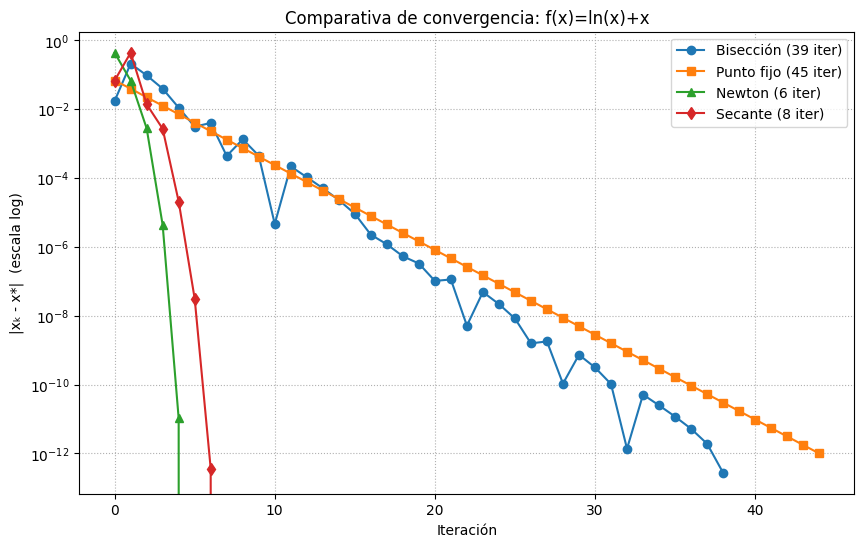


→ Newton y secante llegan a precisión de máquina en MUY pocas iteraciones.
→ Bisección y punto fijo necesitan muchas más.


In [18]:
# Comparativa: misma raíz, mismos puntos iniciales (cuando se puede)
f  = lambda x: np.log(x) + x
df = lambda x: 1/x + 1
g  = lambda x: np.exp(-x)

raiz_exacta = 0.5671432904097838  # raíz de ln(x)+x=0

# Bisección
def biseccion_hist(f, a, b, tol=1e-12):
    hist = []
    while (b-a)/2 > tol:
        x = (a+b)/2
        hist.append(abs(x - raiz_exacta))
        if f(a)*f(x) < 0: b = x
        else: a = x
    return hist

# Punto fijo
def pf_hist(g, x0, tol=1e-12):
    hist = [abs(x0 - raiz_exacta)]
    x = x0
    for _ in range(60):
        x = g(x)
        hist.append(abs(x - raiz_exacta))
        if hist[-1] < tol: break
    return hist

# Newton
def newton_hist(f, df, x0, tol=1e-12):
    hist = [abs(x0 - raiz_exacta)]
    x = x0
    for _ in range(20):
        x = x - f(x)/df(x)
        hist.append(abs(x - raiz_exacta))
        if hist[-1] < 1e-15: break
    return hist

# Secante
def sec_hist(f, x0, x1, tol=1e-12):
    hist = [abs(x0 - raiz_exacta), abs(x1 - raiz_exacta)]
    for _ in range(20):
        f0, f1 = f(x0), f(x1)
        x2 = x1 - f1*(x1-x0)/(f1-f0)
        hist.append(abs(x2 - raiz_exacta))
        x0, x1 = x1, x2
        if hist[-1] < 1e-15: break
    return hist

hb = biseccion_hist(f, 0.1, 1.0)
hp = pf_hist(g, 0.5)
hn = newton_hist(f, df, 1.0)
hs = sec_hist(f, 0.5, 1.0)

plt.figure(figsize=(10, 6))
plt.semilogy(hb, 'o-', label=f"Bisección ({len(hb)} iter)")
plt.semilogy(hp, 's-', label=f"Punto fijo ({len(hp)} iter)")
plt.semilogy(hn, '^-', label=f"Newton ({len(hn)} iter)")
plt.semilogy(hs, 'd-', label=f"Secante ({len(hs)} iter)")
plt.xlabel("Iteración")
plt.ylabel("|xₖ - x*|  (escala log)")
plt.title("Comparativa de convergencia: f(x)=ln(x)+x")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.show()
print("\n→ Newton y secante llegan a precisión de máquina en MUY pocas iteraciones.")
print("→ Bisección y punto fijo necesitan muchas más.")

## 2.6 EJERCICIOS PROPUESTOS — Tema 2

**Ej 2.1 (corto).** Calcula a mano cuántas iteraciones necesita la bisección en $[1, 2]$ para tolerancia $10^{-3}$.

**Ej 2.2 (corto).** Para $f(x) = x^2 - 2$ (raíz $\sqrt{2}$), escribe la iteración de Newton explícita.

**Ej 2.3 (medio).** ¿Cuál de estas reformulaciones $x = g(x)$ converge para resolver $x^2 - 3 = 0$ cerca de $x^* = \sqrt{3}$?
   - (a) $g(x) = 3/x$
   - (b) $g(x) = (x + 3/x)/2$
   - (c) $g(x) = x^2 + x - 3$

**Ej 2.4 (largo).** Implementa los 4 métodos para hallar la raíz de $f(x) = x^3 - x - 1$ cerca de $x_0 = 1.5$. Compara el número de iteraciones para tol=1e-10.

**Ej 2.5 (test).** El método de Newton aplicado a $f(x) = (x-2)^3$ tiene **raíz triple** en $x=2$. ¿Qué orden de convergencia esperas: cuadrático o lineal? **Razona.**


In [26]:
# Ej 2.1
N = (np.log(1) - np.log(2e-3))/np.log(2)
print(f"{N} que son alrededor de 9 its")

8.965784284662087 que son alrededor de 9 its


In [28]:
# Ej 2.2
print("Newton: x_{k+1} = x_k - (x_k² - 2)/(2 x_k) = (x_k + 2/x_k) / 2")

Newton: x_{k+1} = x_k - (x_k² - 2)/(2 x_k) = (x_k + 2/x_k) / 2


In [29]:
# Ej 2.3
"""
Evaluar |g'(x^*)| < 1

a) -3/x^2 -> Insertar sqrt(3) = |-1| Caso limite repulsor
b) (x+3/x)/2 -> 0 < 1
c) ... > 1 -> No converge. Repulsor
"""

"\nEvaluar |g'(x^*)| < 1\n\na) -3/x^2 -> Insertar sqrt(3) = |-1| Caso limite repulsor\nb) (x+3/x)/2 -> 0 < 1\nc) ... > 1 -> No converge. Repulsor\n"

In [35]:
# Ej 2.4
# Biseccion
def f(x):
   return x**3 - x - 1

x_0 = 1.5

def biseccion(f, a, b, tol=1e-10):
   if f(a)*f(b) > 0:
      return None

   iteraciones = 0
   while abs(b - a) > tol:
      x_k = (a + b) / 2
      if f(x_k) * f(a) < 0:
         b = x_k
      elif f(x_k) * f(b) < 0:
         a = x_k
      else:
         break
      iteraciones += 1

   return x_k, iteraciones

raiz, its = biseccion(f, 1, 2)
print(f"Biseccion\t Raiz: {raiz}\t Its: {its}")


Biseccion	 Raiz: 1.324717957235407	 Its: 34


---

# 🟡 BLOQUE 3 — Tema 4A: Derivación Numérica (Diferencias Finitas)

## 3.0 Tabla maestra (memorízala)

Aproximaciones a $f'(x)$ con paso $h$ pequeño:

| Fórmula | Expresión | Error | Evals |
|---|---|---|---|
| **Forward** | $\dfrac{f(x+h)-f(x)}{h}$ | $O(h)$ | 2 |
| **Backward** | $\dfrac{f(x)-f(x-h)}{h}$ | $O(h)$ | 2 |
| **Centrada** | $\dfrac{f(x+h)-f(x-h)}{2h}$ | $O(h^2)$ | 2 |
| **Centrada $f''$** | $\dfrac{f(x+h)-2f(x)+f(x-h)}{h^2}$ | $O(h^2)$ | 3 |

> 💡 La **centrada** es siempre la favorita: mismo coste que forward pero orden cuadrático.

## 3.1 Implementación


In [ ]:
def forward(f, x, h):
    return (f(x+h) - f(x)) / h

def backward(f, x, h):
    return (f(x) - f(x-h)) / h

def centrada(f, x, h):
    return (f(x+h) - f(x-h)) / (2*h)

def segunda_centrada(f, x, h):
    return (f(x+h) - 2*f(x) + f(x-h)) / h**2

# Probamos con f(x) = sin(x) en x = π/4 (derivada exacta = cos(π/4) = √2/2)
f = np.sin
x0 = np.pi/4
exacta = np.cos(x0)

print(f"Derivada exacta en π/4: {exacta:.15f}")
print(f"\n{'h':>10} {'forward':>20} {'centrada':>20} {'err_fw':>12} {'err_c':>12}")
for k in range(1, 14):
    h = 10.0**(-k)
    f_fw = forward(f, x0, h)
    f_c  = centrada(f, x0, h)
    print(f"{h:>10.0e} {f_fw:>20.12f} {f_c:>20.12f} {abs(f_fw-exacta):>12.2e} {abs(f_c-exacta):>12.2e}")

**Lecturas clave del experimento (te las van a preguntar):**

1. La **forward** tiene error $\sim h$: al dividir $h$ entre 10, el error se divide entre 10.
2. La **centrada** tiene error $\sim h^2$: al dividir $h$ entre 10, el error se divide entre 100.
3. **Pero** al bajar mucho h, el error **vuelve a crecer**. ¿Por qué? **Cancelación catastrófica:** el numerador resta dos números casi iguales y el redondeo lo destroza.

## 3.2 El compromiso: $h$ óptimo

Error total = error de discretización (crece con h) + error de redondeo (decrece con h)

$$\mathcal{E}(h) = \mathcal{E}_d + \mathcal{E}_r$$

**Para forward:**
$$h_{\text{opt}} = \sqrt{2\varepsilon_m \left|\frac{f}{f''}\right|} \approx 10^{-8}, \quad \mathcal{E}_{\text{opt}} \approx 10^{-8}$$

**Para centrada:**
$$h_{\text{opt}} = \left(3\varepsilon_m \left|\frac{f}{f'''}\right|\right)^{1/3} \approx 10^{-5}, \quad \mathcal{E}_{\text{opt}} \approx 10^{-11}$$

> 💡 **Tipo test típico:** "¿Con qué h se minimiza el error total de forward?" → $h \approx \sqrt{\varepsilon_m} \approx 10^{-8}$.


In [ ]:
# Gráfica del compromiso
f = np.sin
x0 = 1.0
exacta = np.cos(x0)

hs = np.logspace(-16, 0, 100)
err_fw = [abs(forward(f, x0, h) - exacta) for h in hs]
err_c  = [abs(centrada(f, x0, h) - exacta) for h in hs]

plt.figure(figsize=(10,6))
plt.loglog(hs, err_fw, label="Forward", lw=2)
plt.loglog(hs, err_c,  label="Centrada", lw=2)
plt.axvline(1e-8, ls=":", color="C0", label="h≈√ε ≈ 1e-8 (óptimo forward)")
plt.axvline(1e-5, ls=":", color="C1", label="h≈ε^(1/3) ≈ 1e-5 (óptimo centrada)")
plt.xlabel("h")
plt.ylabel("|error|")
plt.title("Compromiso discretización ↔ redondeo en diferencias finitas")
plt.legend()
plt.grid(True, which="both", ls=":")
plt.show()

## 3.3 EJERCICIOS PROPUESTOS — Derivación Numérica

**Ej 3.1 (corto).** Deriva la fórmula forward desde el desarrollo de Taylor de $f(x+h)$.

**Ej 3.2 (corto).** ¿Cuántas evaluaciones de $f$ necesita la fórmula centrada para $f''(x)$? ¿De qué orden es su error?

**Ej 3.3 (medio).** Calcula $f'(1)$ para $f(x) = e^x$ con $h = 0.1$ usando las tres fórmulas. Compara con $e$.

**Ej 3.4 (test).** Si las diferencias finitas centradas con $h = 10^{-5}$ producen error $10^{-10}$, ¿qué error esperarías con $h = 10^{-6}$? *Cuidado: hay truco.*


In [ ]:
# === SOLUCIONES Tema 3 ===

# Ej 3.1
print("Ej 3.1:")
print("  f(x+h) = f(x) + h·f'(x) + (h²/2)·f''(x) + O(h³)")
print("  Despejando: f'(x) = [f(x+h) - f(x)]/h - (h/2)·f''(ξ) + ...")
print("  Por tanto: forward → error O(h).")

# Ej 3.2
print("\nEj 3.2:")
print("  f''(x) ≈ [f(x+h) - 2f(x) + f(x-h)] / h² → 3 evaluaciones, error O(h²).")

# Ej 3.3
print("\nEj 3.3:")
f = np.exp
x0 = 1.0
h = 0.1
print(f"  forward : {forward(f, x0, h):.10f}  (exacta: {np.e:.10f})")
print(f"  backward: {backward(f, x0, h):.10f}")
print(f"  centrada: {centrada(f, x0, h):.10f}")

# Ej 3.4
print("\nEj 3.4:")
print("  Naivamente: centrada O(h²) → al dividir h entre 10, error /100.")
print("  PERO con h=1e-6 ya estamos cerca del régimen de redondeo:")
print("  el error puede no bajar de 1e-11 (puede incluso EMPEORAR).")
print("  Respuesta cualitativa: ya cerca del óptimo, NO seguirá bajando.")

---

# 🟠 BLOQUE 4 — Tema 4B: EDOs (Problemas de Valor Inicial)

> 🎯 **MUY probable en examen largo.** Especialmente el problema test $y' = \lambda y$.

## 4.0 Planteamiento

Resolver el problema de valor inicial (PVI):
$$y'(t) = f(t, y(t)), \quad y(a) = y_0, \quad t \in [a, b]$$

Discretizamos $a = t_0 < t_1 < \ldots < t_N = b$ con paso $h = (b-a)/N$.
Queremos $y_i \approx y(t_i)$.

## 4.1 EULER EXPLÍCITO (Forward Euler)

**Derivación:** sustituir $y'(t_i) \approx [y(t_{i+1}) - y(t_i)]/h$:
$$\boxed{y_{i+1} = y_i + h \cdot f(t_i, y_i)}$$

- **Error local:** $O(h^2)$
- **Error global:** $O(h)$
- 1 evaluación de $f$ por paso


In [ ]:
def euler_explicito(f, t_span, y0, N):
    """Euler explícito (forward Euler)."""
    a, b = t_span
    t = np.linspace(a, b, N+1)
    h = (b - a) / N
    y = np.zeros(N+1)
    y[0] = y0
    for i in range(N):
        y[i+1] = y[i] + h * f(t[i], y[i])
    return t, y

# Problema test: y' = -y, y(0)=1, solución exacta y(t)=e^(-t)
f = lambda t, y: -y
t, y = euler_explicito(f, (0, 5), 1.0, N=50)

plt.figure(figsize=(10, 5))
plt.plot(t, y, 'o-', label=f"Euler explícito (N=50, h=0.1)", markersize=4)
plt.plot(t, np.exp(-t), 'r--', label="Solución exacta e^(-t)", lw=2)
plt.xlabel("t"); plt.ylabel("y(t)")
plt.title("y' = -y, y(0)=1")
plt.legend(); plt.grid(True)
plt.show()

## 4.2 EULER IMPLÍCITO (Backward Euler)

**Derivación:** usar diferencia hacia atrás en $t_{i+1}$:
$$\boxed{y_{i+1} = y_i + h \cdot f(t_{i+1}, y_{i+1})}$$

⚠️ **$y_{i+1}$ aparece en ambos lados.** Hay que resolver una ecuación no lineal en cada paso (Newton o punto fijo).

- Mismo orden que el explícito: error global $O(h)$
- **Pero:** ¡es **A-estable**! (incondicionalmente estable para $y' = \lambda y$ con $\lambda < 0$)


In [ ]:
def euler_implicito(f, df_y, t_span, y0, N):
    """
    Euler implícito. En cada paso resuelve y_{i+1} = y_i + h·f(t_{i+1}, y_{i+1})
    con Newton. f y df_y son funciones de (t, y).
    """
    a, b = t_span
    t = np.linspace(a, b, N+1)
    h = (b - a) / N
    y = np.zeros(N+1)
    y[0] = y0
    for i in range(N):
        # Resolver F(z) = z - y[i] - h*f(t[i+1], z) = 0  con Newton
        z = y[i]  # inicialización
        for _ in range(50):
            F  = z - y[i] - h * f(t[i+1], z)
            dF = 1 - h * df_y(t[i+1], z)
            z_new = z - F / dF
            if abs(z_new - z) < 1e-12:
                z = z_new
                break
            z = z_new
        y[i+1] = z
    return t, y

# Problema test
f    = lambda t, y: -y
df_y = lambda t, y: -1.0   # ∂f/∂y

t, y_imp = euler_implicito(f, df_y, (0, 5), 1.0, N=50)
print(f"Euler implícito en t=5: {y_imp[-1]:.10f}")
print(f"Solución exacta e^(-5): {np.exp(-5):.10f}")

## 4.3 MÉTODO DE HEUN (Euler mejorado / Predictor-Corrector)

**Idea:** promediar la pendiente en $t_i$ con una **predicción** de la pendiente en $t_{i+1}$.

**Predictor (Euler explícito):** $\tilde{y}_{i+1} = y_i + h \cdot f(t_i, y_i)$

**Corrector (trapecio):** 
$$\boxed{y_{i+1} = y_i + \frac{h}{2}\big[f(t_i, y_i) + f(t_{i+1}, \tilde{y}_{i+1})\big]}$$

- **Error local:** $O(h^3)$
- **Error global:** $O(h^2)$  ← un orden más que Euler
- **2 evaluaciones** de $f$ por paso


In [ ]:
def heun(f, t_span, y0, N):
    """Método de Heun (Euler mejorado)."""
    a, b = t_span
    t = np.linspace(a, b, N+1)
    h = (b - a) / N
    y = np.zeros(N+1)
    y[0] = y0
    for i in range(N):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + h, y[i] + h*k1)   # con el predictor
        y[i+1] = y[i] + 0.5 * h * (k1 + k2)
    return t, y

f = lambda t, y: -y
t, y_h = heun(f, (0, 5), 1.0, N=50)
print(f"Heun en t=5: {y_h[-1]:.10f}")
print(f"Exacta e^(-5): {np.exp(-5):.10f}")

## 4.4 COMPARATIVA: convergencia frente a $h$


In [ ]:
# Verificar el orden de convergencia
f = lambda t, y: -y
exacta_final = np.exp(-5)

Ns = [10, 20, 40, 80, 160, 320, 640]
err_eu, err_he = [], []
hs = []
for N in Ns:
    _, ye = euler_explicito(f, (0, 5), 1.0, N)
    _, yh = heun(f, (0, 5), 1.0, N)
    h = 5.0/N
    hs.append(h)
    err_eu.append(abs(ye[-1] - exacta_final))
    err_he.append(abs(yh[-1] - exacta_final))

plt.figure(figsize=(9,6))
plt.loglog(hs, err_eu, 'o-', label="Euler explícito")
plt.loglog(hs, err_he, 's-', label="Heun")
# Líneas de referencia
plt.loglog(hs, [h for h in hs], 'k--', alpha=0.4, label="O(h)")
plt.loglog(hs, [h**2 for h in hs], 'k:', alpha=0.4, label="O(h²)")
plt.xlabel("h"); plt.ylabel("|error en t=5|")
plt.title("Orden de convergencia")
plt.legend(); plt.grid(True, which="both", ls=":")
plt.show()

print("Euler explícito: pendiente ≈ 1 (orden 1)")
print("Heun: pendiente ≈ 2 (orden 2)")

## 4.5 ⭐ ESTABILIDAD (esto SIEMPRE cae)

**Problema test:** $y' = \lambda y$ con $\lambda < 0$, $y(0) = 1$. Solución exacta: $y(t) = e^{\lambda t} \to 0$.

### Euler explícito en el problema test

$$y_{i+1} = y_i + h \lambda y_i = (1 + h\lambda) y_i \Rightarrow y_i = (1 + h\lambda)^i$$

**Para que $y_i \to 0$:** $|1 + h\lambda| < 1 \Rightarrow -2 < h\lambda < 0 \Rightarrow h < 2/|\lambda|$

| Condición | Comportamiento |
|---|---|
| $\|1 + h\lambda\| < 1$ | converge a 0 ✅ (estable) |
| $\|1 + h\lambda\| = 1$ | oscila (neutral) |
| $\|1 + h\lambda\| > 1$ | diverge ❌ (inestable) |

### Pregunta canónica: $\lambda = -10$, ¿cuál es el $h$ crítico?

$h < 2/10 = 0.2$. Si $h \ge 0.2$ → diverge.


In [ ]:
# Demostración: lambda = -10, varios pasos h
def euler_test(lam, h, T=2.0):
    n = int(T/h)+1
    t = np.linspace(0, n*h, n+1)
    y = np.zeros(n+1)
    y[0] = 1.0
    for i in range(n):
        y[i+1] = y[i] + h * lam * y[i]
    return t, y

lam = -10
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Caso inestable: h=0.4 > 0.2
t1, y1 = euler_test(lam, 0.4)
axes[0].plot(t1, y1, 'o-', label="Euler (h=0.4)")
axes[0].plot(t1, np.exp(lam*t1), 'r--', label="Exacta")
axes[0].set_title("h=0.4 > 2/|λ|=0.2 → DIVERGE")
axes[0].legend(); axes[0].grid(True)

# Caso estable: h=0.1 < 0.2
t2, y2 = euler_test(lam, 0.1)
axes[1].plot(t2, y2, 'o-', label="Euler (h=0.1)")
axes[1].plot(t2, np.exp(lam*t2), 'r--', label="Exacta")
axes[1].set_title("h=0.1 < 0.2 → ESTABLE")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

### Euler **implícito**: A-estabilidad

$$y_{i+1} = y_i + h\lambda y_{i+1} \Rightarrow y_{i+1} = \frac{1}{1 - h\lambda} y_i \Rightarrow y_i = \left(\frac{1}{1-h\lambda}\right)^i$$

Si $\lambda < 0$ y $h > 0$: $|1/(1 - h\lambda)| < 1$ **para cualquier h** → siempre converge a 0. Esto es **A-estabilidad**.

> 💡 **Trade-off práctico:** explícito es barato pero condicionalmente estable. Implícito es caro por paso pero incondicionalmente estable.

## 4.6 EJERCICIOS PROPUESTOS — EDOs

**Ej 4.1 (corto).** Aplica un paso de Euler explícito a $y' = -2y$, $y(0)=1$, $h=0.5$. ¿Cuál es $y_1$?

**Ej 4.2 (corto).** ¿Cuál es el paso máximo $h$ para que Euler explícito sea estable en $y' = -50 y$?

**Ej 4.3 (medio).** Aplica un paso de Heun a $y' = t + y$, $y(0)=1$, $h=0.1$. ¿$y_1$?

**Ej 4.4 (largo).** Resuelve $y' = -y + \sin(t)$, $y(0)=0$ en $[0,10]$ con Euler explícito y Heun. Compara las soluciones gráficamente.

**Ej 4.5 (test).** *El método de Heun tiene error local O(h³). ¿Cuál es su error global?* → **O(h²)**.


In [ ]:
# === SOLUCIONES Tema 4 EDOs ===

# Ej 4.1: y' = -2y, y_0=1, h=0.5
print("Ej 4.1:")
print(f"  y_1 = y_0 + h·f(t_0, y_0) = 1 + 0.5·(-2·1) = 1 - 1 = 0")

# Ej 4.2: estabilidad para lambda=-50
print(f"\nEj 4.2:")
print(f"  Condición: |1 + hλ| < 1  →  h < 2/|λ| = 2/50 = 0.04")

# Ej 4.3: Heun en y'=t+y, y(0)=1, h=0.1
print("\nEj 4.3:")
f = lambda t, y: t + y
t_i, y_i, h = 0.0, 1.0, 0.1
k1 = f(t_i, y_i)                 # = 0 + 1 = 1
y_pred = y_i + h*k1              # = 1 + 0.1·1 = 1.1
k2 = f(t_i + h, y_pred)          # = 0.1 + 1.1 = 1.2
y_1 = y_i + 0.5*h*(k1 + k2)      # = 1 + 0.05·(1+1.2) = 1.11
print(f"  k1 = f(0,1) = {k1}")
print(f"  y_pred = 1 + 0.1·1 = {y_pred}")
print(f"  k2 = f(0.1, 1.1) = {k2}")
print(f"  y_1 = 1 + 0.05·(1+1.2) = {y_1}")

# Ej 4.4
print("\nEj 4.4: ver gráfica")
f = lambda t, y: -y + np.sin(t)
t_e, y_e = euler_explicito(f, (0, 10), 0.0, N=100)
t_h, y_h = heun(f, (0, 10), 0.0, N=100)
plt.figure(figsize=(10,5))
plt.plot(t_e, y_e, label="Euler explícito")
plt.plot(t_h, y_h, label="Heun")
plt.xlabel("t"); plt.ylabel("y(t)")
plt.title("y' = -y + sin(t), y(0)=0")
plt.legend(); plt.grid(True)
plt.show()

# Ej 4.5
print("\nEj 4.5: error local O(h³) → error global O(h²)  [se pierde un orden al acumular].")

---

# 🟣 BLOQUE 5 — Tema 4C: Diferenciación Automática (Números Duales)

## 5.0 Idea central

Las diferencias finitas tienen precisión limitada (~10⁻⁸ forward, ~10⁻¹¹ centrada) por el compromiso $h_d$ vs $h_r$.

**Diferenciación automática (AD):** trabaja con **números**, no con expresiones, y da $f'(x_0)$ con **precisión de máquina**.

## 5.1 Números duales

Un número dual es $\mathbf{a} = a + a'd$ donde $d$ es un símbolo con:
$$d^2 = 0, \quad d \neq 0$$

Análogo a los complejos ($i^2 = -1$), pero aquí $d^2 = 0$.

**Representación:** par ordenado $(a, a')$ donde $a$ = valor, $a'$ = derivada.

## 5.2 Aritmética de duales

Con $\mathbf{a} = (a, a')$ y $\mathbf{b} = (b, b')$:

| Operación | Resultado | Coincide con derivada de... |
|---|---|---|
| $\mathbf{a} \pm \mathbf{b}$ | $(a \pm b,\ a' \pm b')$ | $(f \pm g)' = f' \pm g'$ |
| $\mathbf{a} \cdot \mathbf{b}$ | $(ab,\ ab' + a'b)$ | $(fg)' = fg' + f'g$ |
| $\mathbf{a} / \mathbf{b}$ | $(a/b,\ (a'b - ab')/b^2)$ | $(f/g)' = (f'g - fg')/g^2$ |

**Demostración de la multiplicación:**
$$(a + a'd)(b + b'd) = ab + ab'd + a'bd + a'b'd^2 = ab + (ab' + a'b)d + 0$$

> 💡 Por eso "magia": las reglas del cálculo de derivadas **emergen automáticamente** de la aritmética dual.

## 5.3 Funciones elementales

Para $f$ elemental, se extiende como:
$$f(a + a'd) = f(a) + a' f'(a) d$$

| Función | Resultado |
|---|---|
| $\exp(\mathbf{a})$ | $(e^a,\ a' e^a)$ |
| $\sin(\mathbf{a})$ | $(\sin a,\ a' \cos a)$ |
| $\cos(\mathbf{a})$ | $(\cos a,\ -a' \sin a)$ |
| $\ln(\mathbf{a})$ | $(\ln a,\ a'/a)$ |
| $\mathbf{a}^n$ | $(a^n,\ n a^{n-1} a')$ |


In [ ]:
# Implementación de números duales en Python
class Dual:
    def __init__(self, val, der=0.0):
        self.val = val
        self.der = der

    def __repr__(self):
        return f"({self.val}, {self.der})"

    def __add__(self, other):
        if not isinstance(other, Dual): other = Dual(other, 0)
        return Dual(self.val + other.val, self.der + other.der)
    __radd__ = __add__

    def __sub__(self, other):
        if not isinstance(other, Dual): other = Dual(other, 0)
        return Dual(self.val - other.val, self.der - other.der)
    def __rsub__(self, other):
        return Dual(other, 0) - self

    def __mul__(self, other):
        if not isinstance(other, Dual): other = Dual(other, 0)
        return Dual(self.val * other.val,
                    self.val * other.der + self.der * other.val)
    __rmul__ = __mul__

    def __truediv__(self, other):
        if not isinstance(other, Dual): other = Dual(other, 0)
        return Dual(self.val / other.val,
                    (self.der * other.val - self.val * other.der) / other.val**2)
    def __rtruediv__(self, other):
        return Dual(other, 0) / self

    def __pow__(self, n):
        return Dual(self.val**n, n * self.val**(n-1) * self.der)

    def __neg__(self):
        return Dual(-self.val, -self.der)

# Funciones elementales
def d_exp(a):  return Dual(np.exp(a.val),   a.der * np.exp(a.val))
def d_sin(a):  return Dual(np.sin(a.val),   a.der * np.cos(a.val))
def d_cos(a):  return Dual(np.cos(a.val),  -a.der * np.sin(a.val))
def d_log(a):  return Dual(np.log(a.val),   a.der / a.val)
def d_sqrt(a): return Dual(np.sqrt(a.val),  a.der / (2*np.sqrt(a.val)))

# Para derivar f en x0: instanciar x = Dual(x0, 1) y aplicar f
print("Test: f(x) = x² → f'(x) = 2x")
x = Dual(3.0, 1.0)
f = x * x
print(f"  f(3) = {f.val} (esperado: 9)")
print(f"  f'(3) = {f.der} (esperado: 6)")

In [ ]:
# Ejemplo más completo: f(x) = sin(x²) · exp(x) en x=1
print("Ejemplo: f(x) = sin(x²)·exp(x) en x=1")
print("Derivada analítica: f'(x) = 2x cos(x²) exp(x) + sin(x²) exp(x)")

x_val = 1.0
x = Dual(x_val, 1.0)

# f(x) = sin(x²) · exp(x)
f = d_sin(x * x) * d_exp(x)
print(f"\nCon duales:")
print(f"  f({x_val}) = {f.val:.15f}")
print(f"  f'({x_val}) = {f.der:.15f}")

# Verificación analítica
analitica = 2*x_val*np.cos(x_val**2)*np.exp(x_val) + np.sin(x_val**2)*np.exp(x_val)
print(f"\nAnalítica:  f'({x_val}) = {analitica:.15f}")
print(f"Diferencia: {abs(f.der - analitica):.2e}")

## 5.4 Ejercicio clásico de examen: multiplicar duales **a mano**

> *Calcular $(3 + 2d) \cdot (5 + d)$*

$$
(3 + 2d)(5 + d) = 15 + 3d + 10d + 2d^2 = 15 + 13d + 0 = (15, 13)
$$

**Verificación:** si $a=3, a'=2, b=5, b'=1$:
- $ab = 15$ ✅
- $ab' + a'b = 3 \cdot 1 + 2 \cdot 5 = 13$ ✅


In [ ]:
# Verificamos a mano y con la clase
a = Dual(3, 2)
b = Dual(5, 1)
print(f"(3 + 2d) · (5 + d) = {a*b}")
print(f"Esperado: (15, 13)")

## 5.5 EJERCICIOS PROPUESTOS — Duales

**Ej 5.1 (corto).** Calcula $(2 + 3d) + (1 + d)$.

**Ej 5.2 (corto).** Calcula $(1 + 2d)^2$.

**Ej 5.3 (medio).** Aplica la división dual: $(4 + 2d) / (2 + d)$.

**Ej 5.4 (medio).** Usa la clase Dual para hallar $f'(2)$ siendo $f(x) = (x^2 + 1)/(x - 3)$.

**Ej 5.5 (test).** *La segunda componente de un número dual encapsula:* 
   - (a) el cuadrado del valor
   - (b) la derivada de la función — ✅
   - (c) el error de redondeo


In [ ]:
# === SOLUCIONES Tema 5 ===

print("Ej 5.1: (2+3d) + (1+d) = (3, 4)")
print(f"  Con clase: {Dual(2,3) + Dual(1,1)}")

print("\nEj 5.2: (1+2d)² = 1 + 4d + 4d² = 1 + 4d = (1, 4)")
print("  Regla: (a, a')² = (a², 2·a·a') → (1², 2·1·2) = (1, 4)")
print(f"  Con clase: {Dual(1,2)**2}")

print("\nEj 5.3: (4+2d)/(2+d) = (4/2, (2·2 - 4·1)/2²) = (2, 0)")
print(f"  Con clase: {Dual(4,2) / Dual(2,1)}")

print("\nEj 5.4: f(x) = (x²+1)/(x-3), f'(2)?")
x = Dual(2.0, 1.0)
f = (x*x + 1) / (x - 3)
print(f"  f(2) = {f.val}")
print(f"  f'(2) = {f.der}")
# Verificación: f(x)=(x²+1)/(x-3), f'(x) = [2x(x-3) - (x²+1)]/(x-3)²
exact = (2*2*(2-3) - (4+1)) / (2-3)**2
print(f"  Analítica: {exact}")

print("\nEj 5.5: (b) la derivada de la función")

---

# 🔴 BLOQUE 6 — Tema 6: Integración Numérica

> 🎯 **Probable en ejercicio largo.** El "trabajo de una fuerza" con datos tabulados es el clásico.

## 6.0 Planteamiento

Aproximar $I[f] = \int_a^b f(x)\,dx$ cuando:
- $f$ no tiene primitiva elemental, o
- solo tenemos $f$ en una tabla de valores.

**Fórmula general (Newton-Cotes):**
$$I_N[f] = \sum_{i=0}^{N} w_i \, f(x_i)$$

donde $w_i$ son **pesos** y $x_i$ son **nodos** (equiespaciados en Newton-Cotes).

## 6.1 Tabla maestra (memorízala)

| Regla | Nodos por panel | Pesos | Error compuesto | Grado de exactitud |
|---|---|---|---|---|
| **Punto medio** | 1 | $h$ | $O(h^2)$ | 1 |
| **Trapecio** | 2 (extremos) | $h/2, h/2$ | $O(h^2)$ | 1 |
| **Simpson** | 3 (extremos + medio) | $h/3, 4h/3, h/3$ | $O(h^4)$ | 3 |
| **Gauss-Legendre** ($N+1$ nodos) | $N+1$ (óptimos) | tabulados | — | $2N+1$ |


## 6.2 REGLA DEL TRAPECIO

### Simple
Aproxima $f$ por una recta entre $a$ y $b$:
$$I[f] \approx \frac{b-a}{2}\big[f(a) + f(b)\big]$$

### Compuesta
Divide $[a,b]$ en $N$ paneles de tamaño $h = (b-a)/N$:
$$\boxed{I_N[f] = \frac{h}{2}\big[f(x_0) + 2f(x_1) + 2f(x_2) + \ldots + 2f(x_{N-1}) + f(x_N)\big]}$$

**Pesos:** extremos $h/2$, interiores $h$.

**Error:** $E_N[f] = -\dfrac{(b-a)h^2}{12} f''(\xi) = O(h^2)$.
Al dividir $h$ entre 10, el error se divide entre **100**.


In [ ]:
def trapecio_compuesto(f, a, b, N):
    """Trapecio compuesto: pesos [1,2,2,...,2,1]·(h/2)."""
    x = np.linspace(a, b, N+1)
    y = f(x) if callable(f) else np.array(f)
    h = (b - a) / N
    return h/2 * (y[0] + y[-1] + 2*np.sum(y[1:-1]))

def trapecio_datos(x, y):
    """Trapecio con datos tabulados (paso uniforme)."""
    x, y = np.asarray(x), np.asarray(y)
    h = x[1] - x[0]
    return h/2 * (y[0] + y[-1] + 2*np.sum(y[1:-1]))

# Test: integral de e^x en [0,1], exacto = e - 1
f = np.exp
exact = np.e - 1
print(f"Integral exacta: {exact:.10f}")
for N in [2, 4, 8, 16, 32, 64, 128]:
    I = trapecio_compuesto(f, 0, 1, N)
    print(f"  N={N:3d}: I={I:.10f}, error={abs(I-exact):.2e}")
print("\n👀 al dividir N entre 2, el error se divide entre 4 ≈ O(h²)")

## 6.3 REGLA DE SIMPSON

### Simple ($N=2$, tres nodos)

$$I_2[f] = \frac{h}{3}\big[f(a) + 4f\!\left(\tfrac{a+b}{2}\right) + f(b)\big], \quad h = \frac{b-a}{2}$$

Pesos: $1, 4, 1$ con factor $h/3$.

### Compuesta ($N$ par)

$$\boxed{I_N[f] = \frac{h}{3}\big[f(x_0) + 4f(x_1) + 2f(x_2) + 4f(x_3) + \ldots + 4f(x_{N-1}) + f(x_N)\big]}$$

**Pesos interiores alternan:** $4, 2, 4, 2, \ldots, 4$ (4 en impares, 2 en pares internos).

**Error:** $E_N[f] = -\dfrac{(b-a)h^4}{180} f^{(4)}(\xi) = O(h^4)$.
Al dividir $h$ entre 10, el error se divide entre **10 000**.

⚠️ **$N$ debe ser par.**


In [ ]:
def simpson_compuesto(f, a, b, N):
    """Simpson compuesto. N debe ser PAR."""
    if N % 2 != 0:
        raise ValueError("N debe ser par para Simpson compuesto.")
    x = np.linspace(a, b, N+1)
    y = f(x) if callable(f) else np.array(f)
    h = (b - a) / N
    # Pesos: 1, 4, 2, 4, 2, ..., 4, 1
    return h/3 * (y[0] + y[-1] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2]))

# Mismo test: integral de e^x en [0,1]
print(f"Integral exacta: {exact:.15f}")
for N in [2, 4, 8, 16, 32, 64]:
    I = simpson_compuesto(np.exp, 0, 1, N)
    print(f"  N={N:3d}: I={I:.15f}, error={abs(I-exact):.2e}")
print("\n👀 al dividir N entre 2, el error se divide entre 16 ≈ O(h⁴)")

## 6.4 Grado de exactitud (concepto clave para test)

**Definición:** la regla tiene grado de exactitud $n$ si integra exactamente todos los polinomios hasta grado $n$, pero no $x^{n+1}$.

Para comprobarlo basta verificar sobre los monomios $1, x, x^2, \ldots$

- **Trapecio:** grado **1** (exacto para constantes y rectas)
- **Simpson:** grado **3** (¡un grado más de lo esperado! Cancelación simétrica)
- **Gauss-Legendre con $N+1$ nodos:** grado $2N+1$ (el doble que Newton-Cotes)


In [ ]:
# Demostración: Simpson es EXACTO para x³ a pesar de usar polinomio cuadrático
print("Test: integral de x³ en [0,1]. Exacto = 1/4 = 0.25")
f3 = lambda x: x**3
print(f"  Trapecio N=4:  {trapecio_compuesto(f3, 0, 1, 4):.15f}  (NO exacto)")
print(f"  Simpson N=2:   {simpson_compuesto(f3, 0, 1, 2):.15f}  (EXACTO)")

print("\nTest: integral de x⁴ en [0,1]. Exacto = 1/5 = 0.2")
f4 = lambda x: x**4
print(f"  Simpson N=2:   {simpson_compuesto(f4, 0, 1, 2):.15f}  (ya NO exacto, grado 4 > 3)")

## 6.5 PROBLEMA CANÓNICO DEL EXAMEN: trabajo de una fuerza con datos tabulados

**Contexto:** En mecánica, $W = \int_a^b F(x)\,dx$. Tenemos solo medidas en posiciones equiespaciadas.

| x (m) | 0.0 | 0.1 | 0.2 | 0.3 | 0.4 | 0.5 | 0.6 | 0.7 | 0.8 | 0.9 | 1.0 | 1.1 | 1.2 | 1.3 | 1.4 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| F (N) | 0.0 | 0.45 | 1.45 | 2.3 | 3.1 | 3.1 | 3.1 | 2.5 | 1.1 | 1.1 | 1.1 | 0.8 | 0.6 | 0.3 | 0.0 |

**Estima el trabajo con el trapecio compuesto y representa la interpolante lineal a trozos.**


In [ ]:
# Datos del problema clásico
x = np.arange(0.0, 1.5, 0.1)
y = np.array([0.0, 0.45, 1.45, 2.3, 3.1, 3.1, 3.1,
              2.5, 1.1, 1.1, 1.1, 0.8, 0.6, 0.3, 0.0])

W = trapecio_datos(x, y)
print(f"Trabajo estimado por trapecio: W ≈ {W:.4f} J")

# Visualización: el trapecio integra la interpolante lineal a trozos
plt.figure(figsize=(10, 5))
plt.fill_between(x, y, 0, alpha=0.3, color="C0", label="Área = trapecio compuesto")
plt.plot(x, y, 'o-', color="C0", lw=2, label="Interpolante lineal a trozos")
plt.xlabel("x (m)"); plt.ylabel("F (N)")
plt.title(f"Trabajo realizado por la fuerza ≈ {W:.3f} J")
plt.legend(); plt.grid(True)
plt.show()

## 6.6 Conexión EDO ↔ Integración

La EDO $y'(t) = f(t, y)$ se escribe en forma integral:
$$y(t) = y_0 + \int_a^t f(s, y(s))\,ds$$

Aplicando reglas de cuadratura a la integral se recuperan los métodos para EDOs:

| Regla de cuadratura | Método para EDO |
|---|---|
| Rectángulo izquierdo (forward) | Euler explícito |
| Rectángulo derecho (backward) | Euler implícito |
| Trapecio | Heun |

## 6.7 EJERCICIOS PROPUESTOS — Integración

**Ej 6.1 (corto).** Aplica trapecio simple a $\int_0^2 x^2 \, dx$. Exacto: $8/3 \approx 2.667$.

**Ej 6.2 (corto).** Aplica Simpson simple a $\int_0^1 x^3\,dx$. ¿Por qué da exactamente $1/4$?

**Ej 6.3 (medio).** Aplica trapecio compuesto con $N=4$ a $\int_0^1 \sqrt{x}\,dx$. Compara con el exacto $2/3$.

**Ej 6.4 (largo).** Estima $\int_0^\pi \sin(x)\,dx$ (exacto = 2) con Simpson para $N \in \{2, 4, 8, 16\}$. Grafica el error vs $N$ en escala log-log y comprueba la pendiente $-4$.

**Ej 6.5 (test).** ¿Cuántas evaluaciones de $f$ necesita Simpson compuesto con $N=10$ paneles? → **11** (los nodos $x_0, x_1, \ldots, x_{10}$).


In [ ]:
# === SOLUCIONES Tema 6 ===

# Ej 6.1
print("Ej 6.1: trapecio simple ∫₀² x² dx")
I = (2-0)/2 * (0**2 + 2**2)
print(f"  I = (2/2)·(0 + 4) = {I}  (exacto: 8/3 ≈ 2.667 → mucho error porque x² no es lineal)")

# Ej 6.2
print("\nEj 6.2: Simpson simple ∫₀¹ x³ dx")
h = 0.5
I = h/3 * (0**3 + 4*0.5**3 + 1**3)
print(f"  I = (0.5/3)·(0 + 4·0.125 + 1) = (0.5/3)·1.5 = {I}")
print("  Da exactamente 1/4 porque Simpson tiene grado de exactitud 3 ≥ 3.")

# Ej 6.3
print("\nEj 6.3: trapecio compuesto ∫₀¹ √x dx, N=4")
fsq = np.sqrt
I = trapecio_compuesto(fsq, 0, 1, 4)
print(f"  I ≈ {I:.6f}  (exacto: 2/3 ≈ {2/3:.6f})")
print(f"  Error: {abs(I - 2/3):.4f}  (alto porque √x no es C² en x=0)")

# Ej 6.4
print("\nEj 6.4: Simpson para ∫₀^π sin(x) dx, error vs N")
Ns = [2, 4, 8, 16, 32, 64]
errs = []
for N in Ns:
    I = simpson_compuesto(np.sin, 0, np.pi, N)
    errs.append(abs(I - 2.0))
    print(f"  N={N:3d}: I={I:.10f}, error={abs(I-2):.2e}")

plt.figure(figsize=(8,5))
plt.loglog(Ns, errs, 'o-', label="Error Simpson")
hs = np.array([np.pi/N for N in Ns])
plt.loglog(Ns, hs**4 * errs[0]/hs[0]**4, 'k--', label="Referencia O(h⁴)")
plt.xlabel("N (paneles)"); plt.ylabel("|error|")
plt.title("Convergencia O(h⁴) de Simpson")
plt.legend(); plt.grid(True, which="both", ls=":")
plt.show()

# Ej 6.5
print("\nEj 6.5: Simpson compuesto N=10 → 11 evaluaciones de f (x_0, x_1, ..., x_10)")

---

# 🎯 BLOQUE 7 — Batería tipo test (40 preguntas)

> Tapa la respuesta. Para cada pregunta, **piensa la respuesta** antes de leer la solución.

Estructura:
- **T1:** preguntas 1–6
- **T2:** preguntas 7–14
- **T4A (derivación):** preguntas 15–20
- **T4B (EDOs):** preguntas 21–28
- **T4C (duales):** preguntas 29–32
- **T6 (integración):** preguntas 33–40


### Preguntas 1–6 · Tema 1

**1.** *Si el error absoluto es $\Delta x = -1$ y $x = 10^9$, ¿cuál es el error relativo?*
- (a) $-10^{-9}$ ✅
- (b) $-10^9$
- (c) $-1$

**2.** *La operación `1.1 + 0.1 == 1.2` en Python devuelve:*
- (a) True
- (b) False ✅ (es 1.2000000000000002)

**3.** *¿Cuál es la causa de la cancelación catastrófica?*
- Restar dos números **casi iguales**, lo que dispara el error relativo. ✅

**4.** *Si la suma satisface `(1e20 + (-1e20)) + 1.0 = 0.0`, ¿cómo se llama la propiedad violada?*
- **Asociatividad** ✅

**5.** *En precisión doble, el épsilon de máquina vale aproximadamente:*
- (a) $10^{-8}$
- (b) $2.22 \times 10^{-16}$ ✅
- (c) $10^{-32}$

**6.** *Para evitar cancelación catastrófica en $\sqrt{x+1} - \sqrt{x}$ con $x$ grande, multiplicamos por:*
- el conjugado $\dfrac{\sqrt{x+1} + \sqrt{x}}{\sqrt{x+1} + \sqrt{x}}$, quedando $\dfrac{1}{\sqrt{x+1} + \sqrt{x}}$. ✅


### Preguntas 7–14 · Tema 2 (Raíces)

**7.** *El método de bisección requiere:*
- (a) f continua y f(a)·f(b) < 0 ✅
- (b) f derivable
- (c) un punto inicial

**8.** *La bisección en [0, 1] con tolerancia $10^{-3}$ necesita aproximadamente:*
- $\lceil \log_2(1/(2 \cdot 10^{-3})) \rceil = \lceil 8.97 \rceil = 9$ iteraciones ✅

**9.** *Orden de convergencia del método de Newton (raíz simple):*
- **2 (cuadrática)** ✅

**10.** *¿Qué pasa si Newton se aplica a $f(x) = (x-1)^3$?*
- Raíz triple → convergencia **solo lineal** ✅

**11.** *El método de la secante tiene orden de convergencia:*
- $\phi = \dfrac{1+\sqrt{5}}{2} \approx 1.618$ (número áureo) ✅

**12.** *La iteración de punto fijo $x_{k+1} = g(x_k)$ converge **localmente** si:*
- $|g'(x^*)| < 1$ ✅

**13.** *Para resolver $f(x) = \ln x + x = 0$, una reformulación válida de punto fijo es:*
- $g(x) = e^{-x}$ ✅

**14.** *¿Cuántas evaluaciones de $f$ y $f'$ necesita una iteración de Newton?*
- **1 de $f$ y 1 de $f'$** ✅


### Preguntas 15–20 · Tema 4A (Derivación)

**15.** *Error de la diferencia forward $[f(x+h) - f(x)]/h$:*
- $O(h)$ ✅

**16.** *Error de la diferencia centrada $[f(x+h) - f(x-h)]/(2h)$:*
- $O(h^2)$ ✅

**17.** *El $h$ óptimo aproximado para la fórmula forward es:*
- $h_{\text{opt}} \approx \sqrt{\varepsilon_m} \approx 10^{-8}$ ✅

**18.** *El $h$ óptimo aproximado para la centrada es:*
- $h_{\text{opt}} \approx \varepsilon_m^{1/3} \approx 10^{-5}$ ✅

**19.** *¿Cuántas evaluaciones de $f$ necesita $f''(x)$ con la fórmula centrada $[f(x+h)-2f(x)+f(x-h)]/h^2$?*
- **3** (en $x-h$, $x$, $x+h$) ✅

**20.** *Si reducimos $h$ por debajo del óptimo, ¿qué pasa con el error?*
- **Vuelve a crecer** por dominio del error de redondeo (cancelación catastrófica). ✅


### Preguntas 21–28 · Tema 4B (EDOs)

**21.** *Fórmula del método de Euler explícito:*
- $y_{i+1} = y_i + h \cdot f(t_i, y_i)$ ✅

**22.** *Error global del Euler explícito:*
- $O(h)$ ✅

**23.** *Error global del método de Heun:*
- $O(h^2)$ ✅

**24.** *Para $y' = \lambda y$, $\lambda = -10$, ¿cuál es el paso máximo h para que Euler explícito sea estable?*
- $h < 2/|\lambda| = 0.2$ ✅

**25.** *Si $|1 + h\lambda| > 1$, Euler explícito:*
- **diverge** (inestable) ✅

**26.** *El Euler implícito es:*
- **A-estable** (incondicionalmente estable para $\lambda < 0$) ✅

**27.** *El método de Heun necesita cuántas evaluaciones de $f$ por paso:*
- **2** ✅

**28.** *Heun corresponde a aplicar qué regla de cuadratura a la integral de la EDO:*
- **Trapecio** ✅


### Preguntas 29–32 · Tema 4C (Duales)

**29.** *¿Qué propiedad define los números duales?*
- $d^2 = 0,\ d \neq 0$ ✅

**30.** *Calcular $(3 + 2d) \cdot (5 + d)$:*
- $15 + 13d = (15, 13)$ ✅

**31.** *La regla del producto $(a, a')(b, b') = (ab,\ ab' + a'b)$ es:*
- la regla de la derivada de un producto $(fg)' = fg' + f'g$ ✅

**32.** *Para derivar $f$ en $x_0$ con números duales, instanciamos:*
- $x = (x_0, 1)$ (la 1 indica "estamos derivando respecto a x") ✅


### Preguntas 33–40 · Tema 6 (Integración)

**33.** *Grado de exactitud del trapecio:*
- **1** ✅

**34.** *Grado de exactitud de Simpson:*
- **3** ✅ (no 2, gracias a la cancelación simétrica)

**35.** *Error compuesto del trapecio:*
- $O(h^2)$ ✅

**36.** *Error compuesto de Simpson:*
- $O(h^4)$ ✅

**37.** *Restricción de Simpson compuesto sobre N:*
- $N$ debe ser **par** ✅

**38.** *Pesos del trapecio compuesto:*
- extremos $h/2$, interiores $h$ → $[1, 2, 2, \ldots, 2, 1] \cdot h/2$ ✅

**39.** *Pesos de Simpson compuesto (interiores):*
- alternan $4, 2, 4, 2, \ldots$ (factor $h/3$) ✅

**40.** *Grado de exactitud de Gauss-Legendre con $N+1$ nodos:*
- $2N + 1$ ✅


---

# 🎓 BLOQUE 8 — SIMULACRO DE EXAMEN COMPLETO

> Tiempo recomendado: **2 horas**. Hazlo SIN MIRAR las soluciones.

## Estructura
- **Parte 1 (40%) – Tipo test:** 10 preguntas (al final del notebook).
- **Parte 2 (60%) – Ejercicios:** 2 cortos + 2 largos.

---

## ✏️ Ejercicio 1 (CORTO — 15%)
**Errores y aritmética finita.** 

Dado el sistema de coma flotante con $b = 10$, $t = 4$ (mantisa), $L = -2$, $U = 2$:

(a) Indica el número positivo máximo y mínimo representables.

(b) ¿Qué ocurre al calcular $x \cdot y$ con $x = 0.5678$ e $y = 0.0123$? ¿Hay overflow, underflow o cabe?

(c) Si $\tilde{a} = 1.235 \pm 0.002$ y $\tilde{b} = 1.230 \pm 0.002$, ¿cuál es la cota del error relativo de $\tilde{a} - \tilde{b}$? Comenta el resultado.


## ✏️ Ejercicio 2 (CORTO — 15%)
**Diferenciación automática.**

(a) Verifica simbólicamente la regla del producto en duales: $(a, a')(b, b') = (ab,\ ab' + a'b)$.

(b) Calcula a mano $(2 - d) \cdot (1 + 3d)$.

(c) Usando duales (sin Python), evalúa $f'(0)$ para $f(x) = (x + 1)^3$.


## ✏️ Ejercicio 3 (LARGO — 30%)
**Búsqueda de raíces.**

Considera $f(x) = x e^x - 1$.

(a) Demuestra que $f$ tiene una única raíz en $[0, 1]$.

(b) Implementa el método de Newton en Python. Aplica el método con $x_0 = 0.5$, tolerancia $10^{-10}$. Muestra las iteraciones.

(c) Reformula $f(x) = 0$ como un problema de punto fijo $x = g(x)$ que **converja** y razona por qué. Implementa la iteración con $x_0 = 0.5$ y compara el número de iteraciones con Newton.

(d) ¿Funcionaría el método de bisección en $[0, 1]$? Justifica.

(e) **Conceptual:** Newton converge en pocas iteraciones, pero ¿qué pasaría si $f$ tuviera una raíz doble en lugar de simple?


## ✏️ Ejercicio 4 (LARGO — 30%)
**EDOs e integración.**

Considera el PVI: $y'(t) = -2y + t$, $y(0) = 1$, $t \in [0, 2]$.

(a) Implementa Euler explícito y Heun en Python.

(b) Resuelve el PVI con ambos métodos para $N = 20$ (h=0.1) y representa las soluciones junto con la solución exacta $y(t) = 0.75 e^{-2t} + 0.5t - 0.25$.

(c) Estima el error global de cada método en $t = 2$ usando $N = 10, 20, 40, 80, 160$ y verifica el orden de convergencia con un gráfico log-log.

(d) Comprueba el límite de estabilidad del Euler explícito sobre el problema test $y' = -10 y$. ¿Para qué $h$ diverge?

(e) **Conexión con integración:** la solución exacta cumple
$$y(2) = y(0) + \int_0^2 (-2 y(s) + s)\,ds$$
Si tuvieras $y(s)$ tabulado en 21 puntos equiespaciados, ¿qué regla de cuadratura usarías y por qué? Aplica Simpson compuesto para estimar la integral usando los valores de Heun.


---

# ✅ SOLUCIONES DEL SIMULACRO

> Solo tras intentar los ejercicios.


### Solución Ejercicio 1 (Errores)

**(a)** Con $b=10$, $t=4$, $L=-2$, $U=2$:
- Mantisa máxima: $0.9999$, exponente máximo: $2$ → **máximo $= 0.9999 \times 10^2 = 99.99$**.
- Mantisa mínima normalizada: $0.1000$, exponente mínimo: $-2$ → **mínimo $= 0.1000 \times 10^{-2} = 0.001$**.

**(b)** $x \cdot y = 0.5678 \times 0.0123 = 0.00698394$. 
Normalizando: $0.6984 \times 10^{-2}$ (truncado a $t=4$). 
Exponente $-2 = L$ ✅, mantisa OK → **cabe, no hay overflow ni underflow**.

**(c)** $\tilde{a} - \tilde{b} = 0.005$. Cota error absoluto: $|\Delta a| + |\Delta b| = 0.004$.
Cota relativa: $0.004 / 0.005 = \mathbf{0.8 = 80\%}$ — ¡cancelación catastrófica!


### Solución Ejercicio 2 (Duales)

**(a)** $(a + a'd)(b + b'd) = ab + ab'd + a'bd + a'b'd^2$.
Como $d^2 = 0$: $= ab + (ab' + a'b)d = (ab,\ ab' + a'b)$ ✅

**(b)** $(2 - d)(1 + 3d) = 2 + 6d - d - 3d^2 = 2 + 5d - 0 = (2, 5)$.
Verificación: $a=2, a'=-1, b=1, b'=3$. $ab = 2$ ✅, $ab' + a'b = 2 \cdot 3 + (-1) \cdot 1 = 5$ ✅.

**(c)** $f(x) = (x+1)^3$. Promovemos $x \to (0, 1)$:
$(0 + 1)^3$ en duales: $(0+1, 1) = (1, 1)$ → cubo: $(1, 3 \cdot 1^2 \cdot 1) = (1, 3)$.
Por tanto $f(0) = 1$, $f'(0) = 3$ ✅ (verificación: $f'(x) = 3(x+1)^2 \to f'(0) = 3$).


In [ ]:
# === Solución Ejercicio 3 ===
import numpy as np
import matplotlib.pyplot as plt

# f(x) = x·e^x - 1
f  = lambda x: x*np.exp(x) - 1
df = lambda x: np.exp(x)*(x + 1)

# (a) Demostración existencia/unicidad
print("(a) Existencia y unicidad en [0,1]:")
print(f"   f(0) = {f(0):.4f}   f(1) = {f(1):.4f}   → cambio de signo (Bolzano)")
print(f"   f'(x) = (x+1)·exp(x) > 0 para x ≥ 0  → f estrictamente creciente")
print("   ⇒ raíz ÚNICA en [0,1].")

# (b) Newton
print("\n(b) Newton:")
x = 0.5
for k in range(15):
    x_new = x - f(x)/df(x)
    print(f"   iter {k}: x={x_new:.15f}, |Δ|={abs(x_new-x):.2e}")
    if abs(x_new-x) < 1e-12:
        break
    x = x_new
print(f"   Raíz Newton: {x_new:.15f}")

# (c) Reformulación punto fijo
print("\n(c) Punto fijo. f(x)=0 ⇒ x·e^x = 1 ⇒ x = e^{-x}")
print("   g(x) = e^{-x}, g'(x) = -e^{-x}")
print("   Cerca de la raíz ≈ 0.567: |g'| = e^{-0.567} ≈ 0.567 < 1 → CONVERGE")
g = lambda x: np.exp(-x)
x = 0.5
for k in range(60):
    x_new = g(x)
    if abs(x_new-x) < 1e-12:
        break
    x = x_new
print(f"   Raíz punto fijo: {x_new:.15f}  (en {k} iter)")
print("   Newton converge en ~5 iter; punto fijo en ~30-40. Newton mucho más rápido (cuadrático vs lineal).")

# (d) Bisección
print("\n(d) Bisección en [0,1]: f(0)·f(1) = -1·(e-1) < 0 → SÍ aplica. f es continua.")

# (e) Raíz doble
print("\n(e) Si la raíz fuera DOBLE, f'(x*)=0 y Newton perdería su orden cuadrático,")
print("   bajando a CONVERGENCIA LINEAL.")

In [ ]:
# === Solución Ejercicio 4 ===

# f(t, y) = -2y + t
f_edo = lambda t, y: -2*y + t

# Solución exacta
y_exacta = lambda t: 0.75*np.exp(-2*t) + 0.5*t - 0.25

def euler_exp(f, t_span, y0, N):
    a, b = t_span
    t = np.linspace(a, b, N+1); h = (b-a)/N
    y = np.zeros(N+1); y[0] = y0
    for i in range(N):
        y[i+1] = y[i] + h*f(t[i], y[i])
    return t, y

def heun_m(f, t_span, y0, N):
    a, b = t_span
    t = np.linspace(a, b, N+1); h = (b-a)/N
    y = np.zeros(N+1); y[0] = y0
    for i in range(N):
        k1 = f(t[i], y[i])
        k2 = f(t[i]+h, y[i]+h*k1)
        y[i+1] = y[i] + 0.5*h*(k1+k2)
    return t, y

# (b) Solución para N=20
t, ye = euler_exp(f_edo, (0,2), 1.0, N=20)
_, yh = heun_m(f_edo, (0,2), 1.0, N=20)
texact = np.linspace(0, 2, 200)

plt.figure(figsize=(10,5))
plt.plot(texact, y_exacta(texact), 'k-', lw=2, label="Exacta")
plt.plot(t, ye, 'o-', label="Euler exp.")
plt.plot(t, yh, 's-', label="Heun")
plt.xlabel("t"); plt.ylabel("y")
plt.title("y' = -2y+t, y(0)=1, N=20")
plt.legend(); plt.grid(True)
plt.show()

# (c) Orden de convergencia
print("\n(c) Orden de convergencia (error en t=2):")
Ns = [10, 20, 40, 80, 160]
ye_err, yh_err = [], []
y_T = y_exacta(2.0)
for N in Ns:
    _, ye = euler_exp(f_edo, (0,2), 1.0, N)
    _, yh = heun_m(f_edo, (0,2), 1.0, N)
    ye_err.append(abs(ye[-1] - y_T))
    yh_err.append(abs(yh[-1] - y_T))
    print(f"   N={N:3d}: err_Euler={ye_err[-1]:.2e}, err_Heun={yh_err[-1]:.2e}")

plt.figure(figsize=(8,5))
hs = [2/N for N in Ns]
plt.loglog(hs, ye_err, 'o-', label="Euler O(h)")
plt.loglog(hs, yh_err, 's-', label="Heun O(h²)")
plt.loglog(hs, hs, 'k--', alpha=0.4, label="O(h)")
plt.loglog(hs, [h**2 for h in hs], 'k:', alpha=0.4, label="O(h²)")
plt.xlabel("h"); plt.ylabel("|error en t=2|")
plt.title("Orden de convergencia")
plt.legend(); plt.grid(True, which="both", ls=":")
plt.show()

# (d) Estabilidad: y'=-10y, h crítico = 0.2
print("\n(d) Estabilidad Euler para y'=-10y:")
print("   h crítico = 2/|λ| = 2/10 = 0.2")
print("   Si h ≥ 0.2 → diverge. Si h < 0.2 → converge.")
for h in [0.1, 0.2, 0.25, 0.3]:
    n = int(2/h)
    y = 1.0
    for _ in range(n):
        y = y + h*(-10*y)
    print(f"   h={h}: y(final) = {y:.4e}")

# (e) Simpson sobre la integral
print("\n(e) Con 21 puntos equiespaciados (N=20 par), Simpson compuesto es ideal:")
print("   error O(h⁴) vs O(h²) del trapecio.")
t, yh = heun_m(f_edo, (0,2), 1.0, N=20)
integrando = -2*yh + t   # f(t,y(t))
# Simpson compuesto
h = t[1] - t[0]
I_simp = h/3 * (integrando[0] + integrando[-1]
               + 4*np.sum(integrando[1:-1:2])
               + 2*np.sum(integrando[2:-2:2]))
print(f"   ∫₀² f(s,y(s)) ds ≈ {I_simp:.6f}")
print(f"   y(0) + integral = {1 + I_simp:.6f}")
print(f"   y_exacta(2) = {y_exacta(2):.6f}")
print(f"   Confirma la consistencia del PVI con su forma integral.")

---

# 🎉 ¡Llegaste al final!

## Checklist de últimas 12 horas antes del examen

- [ ] Repasar la **tabla maestra** de cada bloque (la del principio)
- [ ] Memorizar las **5 fórmulas críticas**:
  1. Newton: $x_{k+1} = x_k - f(x_k)/f'(x_k)$
  2. Secante: $x_{k+1} = x_k - f(x_k)(x_k-x_{k-1})/(f(x_k)-f(x_{k-1}))$
  3. Diferencia centrada: $[f(x+h)-f(x-h)]/(2h)$, error $O(h^2)$
  4. Euler explícito: $y_{i+1} = y_i + h \cdot f(t_i, y_i)$
  5. Heun: $y_{i+1} = y_i + (h/2)[f(t_i,y_i) + f(t_{i+1}, \tilde{y}_{i+1})]$
- [ ] Saber **derivar** la condición de estabilidad de Euler: $h < 2/|\lambda|$
- [ ] Saber **multiplicar 2 duales** a mano
- [ ] Conocer los **órdenes de convergencia** de cada método (tablas maestras)
- [ ] Releer las preguntas del Bloque 7 (test)

## Si te falta tiempo

**Prioridad 1 (no negociable):** Bloques 2, 4, 6 y todo el Bloque 7.
**Prioridad 2:** Bloque 5 (duales) — corto pero cae fácil.
**Prioridad 3:** Bloques 1 y 3 — más bien para test.

---

**¡Suerte!** 🍀 Si llegas con todo esto interiorizado, sacarás el examen.
